# 3.2 — The minimum-variance hedge ratio

> *"Regression is the workhorse of empirical finance; the hedge ratio is the one place where its slope
> is a position you actually put on."*

## The problem

We have used $h^* = \rho\,\sigma_S/\sigma_F$ since Chapter 1.4 without proving it, and we have computed
it from data without asking how *reliable* the number is. Both gaps matter: a hedge ratio of 0.62 ± 0.02
and one of 0.62 ± 0.30 call for very different behaviour (the second says: you barely know the ratio, so
be humble, and maybe do not trade the difference from 1:1).

This chapter:

1. **derives** $h^*$ from first principles and shows it is the slope of an ordinary least-squares
   regression (details in [Appendix A](../appendix/A_least_squares.ipynb));
2. shows that **hedge effectiveness equals $R^2$**;
3. attaches **error bars** to $h^*$ — analytically and by bootstrap;
4. settles the practical question of what to regress on: price *changes*, *returns*, or *levels*.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_hub_history, simulate_curve_history
from gashedge.hedging import ols, min_variance_hedge_ratio, hedge_effectiveness
from gashedge.plotting import plot_scatter_fit
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch3.2")
log.info("Environment ready")

2026-09-13 16:47:12.354 | INFO    | ch3.2 | Environment ready


## 1. Derivation

Hold one unit of $S$, sell $h$ units of $F$. The hedged change is $\Delta S - h\,\Delta F$, with variance

$$
V(h) = \sigma_S^2 - 2h\,\text{Cov}(\Delta S,\Delta F) + h^2\sigma_F^2
\tag{3.7}
$$

a convex parabola in $h$. Minimise: $V'(h) = -2\,\text{Cov} + 2h\sigma_F^2 = 0$, so

$$
h^{*} = \frac{\text{Cov}(\Delta S,\Delta F)}{\text{Var}(\Delta F)} = \rho\,\frac{\sigma_S}{\sigma_F}
\tag{3.8}
$$

and the minimised variance is

$$
V(h^*) = \sigma_S^2 - \frac{\text{Cov}^2}{\sigma_F^2} = \sigma_S^2\,(1-\rho^2)
\tag{3.9}
$$

The hedge removes exactly the fraction $\rho^2$ of the variance and **no more**, whatever the sizes.
Two consequences worth stating plainly:

* Because $V(h)$ is a parabola, being wrong by $\epsilon$ in the ratio costs $\epsilon^2\sigma_F^2$ of
  variance — *quadratic*, so small errors are cheap and large errors expensive.
* The 1:1 hedge is optimal only when $\rho\sigma_S = \sigma_F$. For same-tenor, same-hub hedges that
  is nearly true; for anything else it is not.

## 2. It is a regression

Ordinary least squares fits $\Delta S_t = \alpha + \beta\,\Delta F_t + \varepsilon_t$ by minimising
$\sum_t \varepsilon_t^2$. Appendix A shows the solution is $\hat\beta = \widehat{\text{Cov}}/\widehat{\text{Var}}$ —
**identical to (3.8) with sample moments**. So the hedge ratio is the OLS slope, the residual
$\varepsilon_t$ is the hedged P&L per MWh (minus a constant), and

$$
R^2 = 1 - \frac{\sum\varepsilon_t^2}{\sum(\Delta S_t - \overline{\Delta S})^2} = \hat\rho^2 = \text{hedge effectiveness}
\tag{3.10}
$$

This equivalence (Ederington, 1979) is why every hedging desk owns a regression library.

2026-09-13 16:47:12.363 | INFO    | gashedge.market_data | Simulated 750 days of hub history (crisis=False); TTF range 21.7-59.9


2026-09-13 16:47:12.364 | INFO    | ch3.2 | h* by formula (3.8) = 1.0054 ; OLS slope = 1.0054 ; R2 = 0.9259 ; effectiveness = 0.9259


,coef,std_err,t_stat
const,-0.0013,0.0144,-0.0916
dTTF,1.0054,0.0104,96.6389


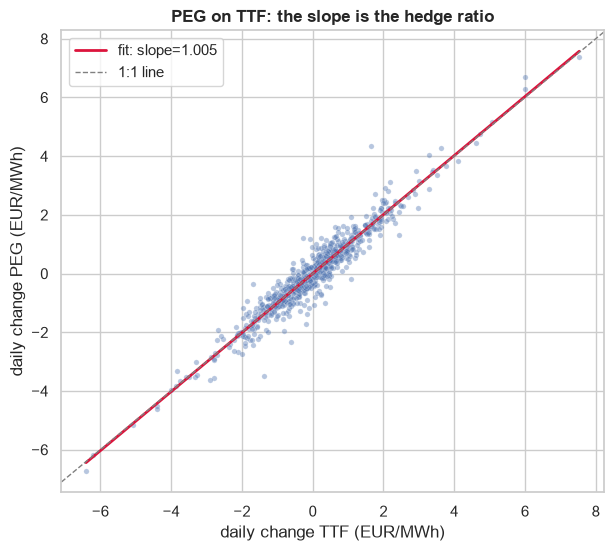

In [2]:
hubs = simulate_hub_history(n_days=750, crisis=False)
dS, dF = hubs.PEG.diff().dropna(), hubs.TTF.diff().dropna()
fit = ols(dS.values, dF.values, names=["dTTF"])
h_formula = min_variance_hedge_ratio(dS, dF)
log.info("h* by formula (3.8) = %.4f ; OLS slope = %.4f ; R2 = %.4f ; effectiveness = %.4f",
         h_formula, fit.beta[1], fit.r2, hedge_effectiveness(dS, dF, h_formula))
fig, ax = plt.subplots(figsize=(7, 6))
plot_scatter_fit(dF.values, dS.values, fit.beta[0], fit.beta[1], "daily change TTF (EUR/MWh)", "daily change PEG (EUR/MWh)",
                 ax=ax, title="PEG on TTF: the slope is the hedge ratio")
fit.summary().round(4)

## 3. How wrong can the ratio be? Standard errors

OLS also hands us the uncertainty of the slope. Under the classical assumptions (Appendix A),

$$
\text{se}(\hat h) = \frac{\hat\sigma_\varepsilon}{\hat\sigma_F\sqrt{n}}
= \frac{\sigma_S}{\sigma_F}\sqrt{\frac{1-\rho^2}{n}}
\tag{3.11}
$$

Three things drive the error bar: the residual noise $\sigma_\varepsilon = \sigma_S\sqrt{1-\rho^2}$ (a
better hedge is also a *better-estimated* hedge), the variance of the hedge instrument (a lively $F$
identifies the slope well), and the sample size — with the usual $\sqrt{n}$. Let us see the bar shrink
as we add data.

,n_days,h_hat,se,ci_low,ci_high,R2
0,20,1.1701,0.0964,0.9812,1.3589,0.8912
1,40,1.2212,0.0839,1.0567,1.3857,0.8478
2,60,1.1384,0.0748,0.9918,1.2850,0.7998
3,120,1.0336,0.0373,0.9606,1.1067,0.8669
4,250,0.9982,0.0239,0.9514,1.0450,0.8759
5,500,1.0052,0.0129,0.9799,1.0306,0.9238
6,749,1.0054,0.0104,0.9850,1.0258,0.9259


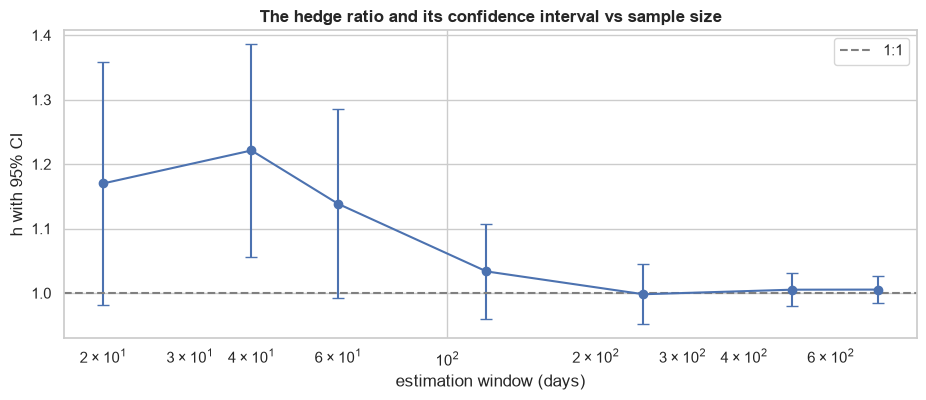

In [3]:
rows = []
for n in (20, 40, 60, 120, 250, 500, 749):
    f = ols(dS.values[-n:], dF.values[-n:], names=["dTTF"])
    rows.append({"n_days": n, "h_hat": f.beta[1], "se": f.se[1], "ci_low": f.beta[1] - 1.96 * f.se[1],
                 "ci_high": f.beta[1] + 1.96 * f.se[1], "R2": f.r2})
se_tbl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 4))
ax.errorbar(se_tbl.n_days, se_tbl.h_hat, yerr=1.96 * se_tbl.se, fmt="o-", capsize=4)
ax.axhline(1.0, color="0.5", ls="--", label="1:1"); ax.set_xscale("log"); ax.legend()
ax.set_xlabel("estimation window (days)"); ax.set_ylabel("h with 95% CI"); ax.set_title("The hedge ratio and its confidence interval vs sample size")
se_tbl.round(4)

With a month of data the interval comfortably contains 1.0 — you *cannot tell* the optimal ratio from a
1:1 hedge, and equation (2.4)'s cost term says: do not pay spread to trade a difference you cannot
measure. With two years of data the bar is tight. But two years of data assume the relationship was
*stable* for two years — the tension Chapter 3.5 lives in.

## 4. Error bars without assumptions: the bootstrap

Formula (3.11) assumes homoskedastic, uncorrelated residuals — false for gas (volatility clusters). A
**block bootstrap** — resample blocks of consecutive days, re-fit, repeat — gives a distribution of
$\hat h$ that respects the data's own quirks.

2026-09-13 16:47:12.693 | INFO    | ch3.2 | n= 60: analytic se 0.0748 | bootstrap sd 0.0976 | bootstrap 95% [0.917, 1.298]


2026-09-13 16:47:12.791 | INFO    | ch3.2 | n=250: analytic se 0.0239 | bootstrap sd 0.0249 | bootstrap 95% [0.938, 1.036]


2026-09-13 16:47:12.908 | INFO    | ch3.2 | n=749: analytic se 0.0104 | bootstrap sd 0.0091 | bootstrap 95% [0.986, 1.022]


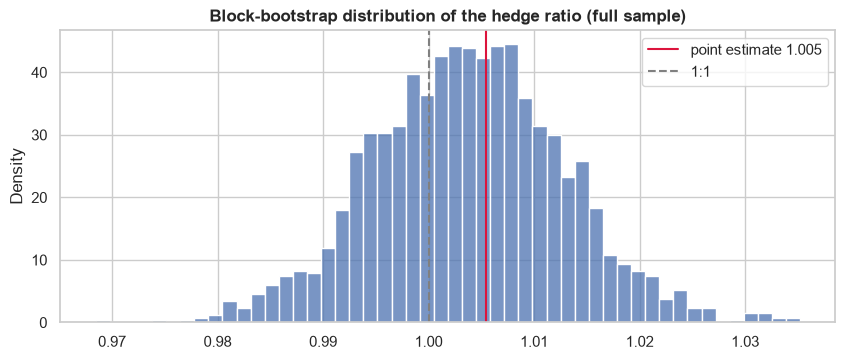

In [4]:
def block_bootstrap_h(dS, dF, n_boot=2000, block=10, seed=0):
    rng = np.random.default_rng(seed)
    n = len(dS)
    idx_blocks = np.arange(0, n - block + 1)
    out = np.empty(n_boot)
    s, f = np.asarray(dS), np.asarray(dF)
    for b in range(n_boot):
        starts = rng.choice(idx_blocks, size=n // block + 1)
        idx = np.concatenate([np.arange(st, st + block) for st in starts])[:n]
        out[b] = np.cov(s[idx], f[idx], ddof=1)[0, 1] / np.var(f[idx], ddof=1)
    return out

for n in (60, 250, 749):
    boot = block_bootstrap_h(dS.values[-n:], dF.values[-n:])
    f = ols(dS.values[-n:], dF.values[-n:])
    log.info("n=%3d: analytic se %.4f | bootstrap sd %.4f | bootstrap 95%% [%.3f, %.3f]", n, f.se[1], boot.std(),
             *np.quantile(boot, [0.025, 0.975]))
boot = block_bootstrap_h(dS.values, dF.values)
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.histplot(boot, bins=50, stat="density", ax=ax); ax.axvline(h_formula, color="crimson", label=f"point estimate {h_formula:.3f}")
ax.axvline(1.0, color="0.5", ls="--", label="1:1"); ax.legend(); ax.set_title("Block-bootstrap distribution of the hedge ratio (full sample)");

## 5. Changes, returns, or levels?

Three ways to run the regression, and only two are defensible:

| regress | ratio means | use when |
|---|---|---|
| $\Delta S$ on $\Delta F$ (EUR/MWh changes) | **MWh of F per MWh of S** — directly a position | hedging a fixed MWh exposure (our case) |
| $\Delta\ln S$ on $\Delta\ln F$ (log returns) | **EUR of F per EUR of S** — multiply by $S/F$ to get MWh | when volatility scales with price level (it does in gas) |
| $S$ on $F$ (levels) | nothing useful | never — spurious regression (Chapter 1.5) |

Changes and returns give the same MWh hedge *if* the price ratio $S/F$ is stable; when it is not (hubs
decoupling, or M1 vs M12 with different levels), the returns regression is usually more stable because
it removes the level effect, and you convert:

$$
h_{\text{MWh}} = \beta_{\text{log}}\cdot\frac{S}{F}
\tag{3.12}
$$

In [5]:
curve = simulate_curve_history(n_days=750, n_tenors=24)
S12, F1 = curve.M12, curve.M1
chg = ols(S12.diff().dropna().values, F1.diff().dropna().values)
ret = ols(np.log(S12).diff().dropna().values, np.log(F1).diff().dropna().values)
lvl = ols(S12.values, F1.values)
price_ratio = (S12 / F1).iloc[-1]
comparison = pd.DataFrame({
    "regression": ["changes", "log-returns", "levels"],
    "slope": [chg.beta[1], ret.beta[1], lvl.beta[1]],
    "implied MWh hedge ratio": [chg.beta[1], ret.beta[1] * price_ratio, np.nan],
    "R2": [chg.r2, ret.r2, lvl.r2],
})
log.info("M12 on M1: changes slope %.3f, returns slope %.3f x S/F %.2f = %.3f; levels R2 %.3f is meaningless", chg.beta[1], ret.beta[1], price_ratio, ret.beta[1] * price_ratio, lvl.r2)
comparison.round(3)

2026-09-13 16:47:13.110 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


2026-09-13 16:47:13.111 | INFO    | ch3.2 | M12 on M1: changes slope 0.361, returns slope 0.419 x S/F 0.65 = 0.272; levels R2 0.904 is meaningless


,regression,slope,implied MWh hedge ratio,R2
0,changes,0.361,0.361,0.551
1,log-returns,0.419,0.272,0.565
2,levels,0.456,NaN,0.904


## 6. From ratio to ticket

The ratio is per MWh. The ticket is in lots of a specific contract (Chapter 1.1):

$$
n_{\text{lots}} = \text{round}\!\left(\frac{h^*\,Q_S}{H_F}\right)
\tag{3.13}
$$

and, as Chapter 2.1 showed, a small position with a wide confidence interval may round to *not trading
the difference from 1:1 at all*. A production engine carries $\hat h$, its standard error, and the last
re-estimation date on every hedge line — so the trader can see *how much of the hedge is model*.

## 7. Where this leaves us

The minimum-variance ratio is the OLS slope of changes; effectiveness is $R^2$; the standard error
scales as $\sqrt{(1-\rho^2)/n}$; use changes or returns, never levels. This is the "linear method" you
were told about, in full.

**Pitfall that leads to the next chapter:** one exposure, one hedge instrument. A book has dozens of
tenors, and the liquid instruments are few. Hedging each tenor separately against M1 ignores that the
residuals are *correlated with each other* — and that a second instrument (say M6) could mop up what M1
leaves behind. Multiple regression, and the factor structure that makes it tractable, is Chapter 3.3.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** From a 120-day sample: $\hat\sigma_{\Delta S} = 1.30$, $\hat\sigma_{\Delta F} = 1.20$, $\hat\rho = 0.90$. Compute $\hat h$, the hedge effectiveness, the standard error of $\hat h$ via (3.11), and a 95 % confidence interval. Does it contain 1?

<details><summary><i>Answer 1</i></summary>

$\hat h = 0.90\times1.30/1.20 = \mathbf{0.975}$. Effectiveness $=\rho^2 = \mathbf{0.81}$. $\text{se} = (1.30/1.20)\sqrt{(1-0.81)/120} = 1.0833\times\sqrt{0.001583} = 1.0833\times0.0398 = \mathbf{0.043}$. 95 % CI $\approx 0.975 \pm 0.084 = [\mathbf{0.891, 1.059}]$ — yes, it contains 1. With this sample you cannot reject 1:1; trading a 2.5 % under-hedge would be trading noise.

</details>

**Q2.** Using (3.7), how much *extra* variance (as a fraction of the unhedged variance) do you carry if you use $h = 1$ when the true optimum is $h^* = 0.6$, with $\sigma_S = 1.0$, $\sigma_F = 1.5$?

<details><summary><i>Answer 2</i></summary>

$V(h) - V(h^*) = (h-h^*)^2\sigma_F^2 = 0.16\times2.25 = 0.36$. Relative to $\sigma_S^2 = 1$: **36 % of the unhedged variance** is added by the sizing error alone. Since $h^* = \rho\sigma_S/\sigma_F \Rightarrow \rho = 0.6\times1.5 = 0.9$, the optimal hedge leaves $1-\rho^2 = 0.19$; the 1:1 hedge leaves $0.19 + 0.36 = 0.55$. Mis-sizing nearly triples the residual — the quadratic penalty in action.

</details>

**Q3.** Why is the standard error of the hedge ratio *smaller* when the hedge is *better* (higher $\rho$), holding $n$ fixed? Give the formula and an intuition.

<details><summary><i>Answer 3</i></summary>

From (3.11), $\text{se}(\hat h) = (\sigma_S/\sigma_F)\sqrt{(1-\rho^2)/n}$: the numerator of the noise is the residual standard deviation $\sigma_S\sqrt{1-\rho^2}$. Intuition: the slope is identified by how tightly the scatter hugs a line; if $F$ explains almost all of $S$'s variation, the points lie close to the line and its slope is pinned down precisely. A poor proxy ($\rho$ low) leaves a wide cloud through which many slopes fit almost equally well — and the same poorness that makes the hedge weak makes its ratio uncertain. Bad hedges are doubly bad.

</details>

**Q4.** A colleague regresses PEG *log returns* on TTF *log returns*, gets $\beta = 0.98$, and sells 0.98 MWh of TTF per MWh of PEG. PEG trades at 42 and TTF at 35. What is the correct MWh ratio, and how large is the error in lots on a 100,000 MWh PEG position (744-hour month)?

<details><summary><i>Answer 4</i></summary>

Returns slope is EUR-per-EUR; convert with (3.12): $h_{\text{MWh}} = 0.98\times42/35 = \mathbf{1.176}$. Correct hedge $= 117{,}600$ MWh $= 158$ lots; the colleague sells $98{,}000$ MWh $= 132$ lots — **under-hedged by ~26 lots (19,600 MWh)**, i.e. leaving a fifth of the position's TTF-correlated risk on the table. The error grows with the hub premium: it is precisely when PEG is expensive relative to TTF (a stressed French market) that the mistake is largest.

</details>


---
◀ [Previous](01_linear_model.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](03_multi_instrument_and_pca.ipynb)